In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
df=pd.read_parquet("../data/merged/winsor_dataset.parquet")

a) Produce a bar chart and a pie chart showing the distribution of loan_status. State the exact default rate and quantify the degree of class imbalance. Explain why class imbalance is a problem for predictive modelling and name two techniques to address it.

In [8]:
loan_count=df['loan_status'].value_counts()
print(loan_count)

loan_status
0    1922444
1      77556
Name: count, dtype: int64


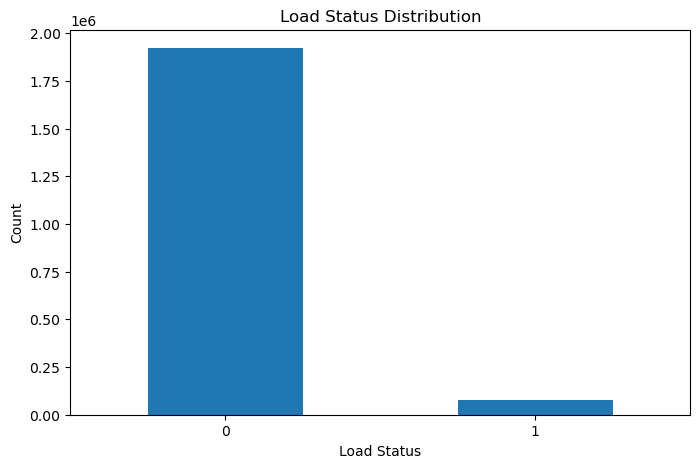

In [9]:
plt.figure(figsize=(8,5))
loan_count.plot(kind="bar")

plt.title('Load Status Distribution')
plt.xlabel('Load Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

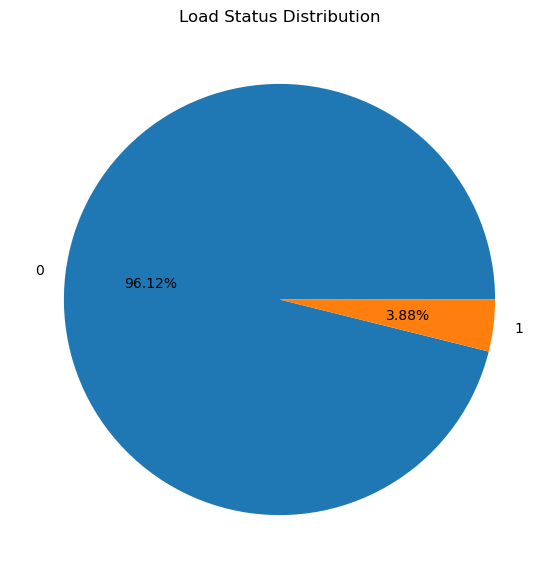

In [10]:
plt.figure(figsize=(7,7))

loan_count.plot(
    kind="pie",
    autopct="%1.2f%%"
)
plt.ylabel("")
plt.title('Load Status Distribution')
plt.show()

In [11]:
# Assuming : 0 = Non-default, 1 = Default
default_rate=(df['loan_status'].mean()*100)
print(f"Default Rate: {default_rate:.2f}%")

Default Rate: 3.88%


In [12]:
# Degree of Class Imbalance
df['loan_status'].value_counts(normalize=True)*100

loan_status
0    96.1222
1     3.8778
Name: proportion, dtype: float64

KDE Curve - A Kernel Density Estimation (KDE) curve is a smooth, continuous line used to represent the probability distribution of a dataset


In [14]:
# loan_status=1 -> Defaulted
# loan_status=0 -> Performing
defaulted=df.loc[df['loan_status']==1,'cibil_score']
performing=df.loc[df['loan_status']==0,'cibil_score']

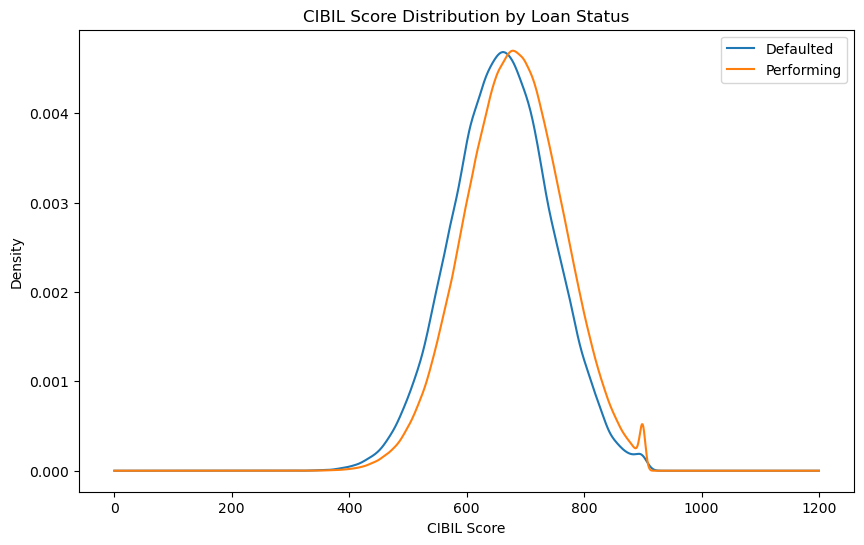

In [15]:
plt.figure(figsize=(10,6))
defaulted.plot.kde(label='Defaulted')
performing.plot.kde(label='Performing')

plt.xlabel('CIBIL Score')
plt.ylabel('Density')
plt.title('CIBIL Score Distribution by Loan Status')
plt.legend()
plt.show()

In [16]:
mean_default = defaulted.mean()
mean_performing = performing.mean()

print("Defaulted Mean:", round(mean_default,2))
print("Performing Mean:", round(mean_performing,2))

Defaulted Mean: 660.11
Performing Mean: 680.68


Cohen's d measures how far apart the two distributions are.

In [17]:

n1 = len(defaulted)
n2 = len(performing)

s1 = defaulted.std()
s2 = performing.std()

pooled_std = np.sqrt(
    ((n1-1)*s1**2 + (n2-1)*s2**2)
    /
    (n1+n2-2)
)

cohens_d = (
    mean_performing - mean_default
) / pooled_std

print("Cohen's d =", round(cohens_d,3))

Cohen's d = 0.243


In [18]:
from scipy.stats import norm

overlap = 2 * norm.cdf(-abs(cohens_d)/2)

print("Distribution Overlap =", round(overlap*100,2), "%")

Distribution Overlap = 90.31 %


In [19]:
summary = pd.DataFrame({
    "Metric":[
        "Mean CIBIL (Defaulted)",
        "Mean CIBIL (Performing)",
        "Cohen's d",
        "Distribution Overlap (%)"
    ],
    "Value":[
        mean_default,
        mean_performing,
        cohens_d,
        overlap*100
    ]
})

summary.round(2)

,Metric,Value
0,Mean CIBIL (Defaulted),660.11
1,Mean CIBIL (Performing),680.68
2,Cohen's d,0.24
3,Distribution Overlap (%),90.31


In [21]:
df['loan_status'].value_counts()

loan_status
0    1922444
1      77556
Name: count, dtype: int64